In [69]:
from src.utils import get_path, find_closest_power_of_2
from src.QDDPM_torch_angel import QDDPM, WassDistance
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch

# Fake config file to use get_path()
# EDITABLE
config = {
    'dataset': {
        'dir': './data',
        'name': 'MNIST0',
    }
}
n_data, n_pixels, n_timesteps, n_ancilla_qubits, n_backward_layers  = 1000, 64, 20, 4, 9
_, n_qubits = find_closest_power_of_2(n_pixels, return_power=True)
diffusion_schedule = 'lin2.5T'

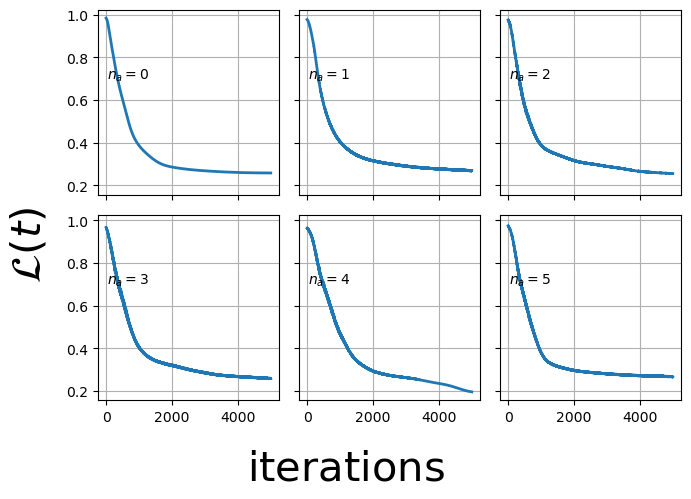

In [70]:
# Plot loss según el parametro que quieras
TIMESTEP = 1
values = range(6)

size = 5
n_cols = 3
n_rows = 2
fig, axs = plt.subplots(n_rows, n_cols, figsize=(size+2, size), sharex=True, sharey=True)
for i, value in enumerate(values):
    n_ancilla_qubits = value

    dir, filename = get_path(config, type='modelsinglefinallosshist', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=TIMESTEP)
    loss = np.load(dir / filename)

    axs[i//n_cols, i%n_cols].plot(loss, lw=2)
    axs[i//n_cols, i%n_cols].text(x=30, y=0.7, s=r'$n_a=%d$'%(value), fontsize=10)
    axs[i//n_cols, i%n_cols].grid(True)

fig.supxlabel(r'$\rm iterations$', fontsize=30)
fig.supylabel(r'$\mathcal{L}(t)$', fontsize=30)
plt.tight_layout()

In [46]:
states[1]

tensor([[0.0002-1.0165e-05j, 0.0015-3.7132e-05j, 0.0029-7.8635e-05j,
          ..., 0.0000+0.0000e+00j, 0.0000+0.0000e+00j,
         0.0000+0.0000e+00j]])

Denoised image at t=0.                     Input at t=1


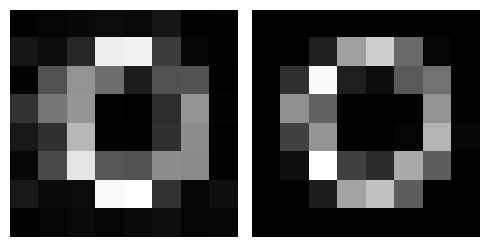

In [51]:
# Visualize the evolution of one image

# Compute the images across timesteps.
device = torch.device('cpu')
model = QDDPM(n_qubits, n_ancilla_qubits, n_timesteps, n_backward_layers, device=device).to(device)

n = 0 # select a sample
dir, filename = get_path(config, type='diffusedqstates', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits,n_timesteps=n_timesteps)
states_diffused = np.load(dir / filename)
state_diffused = states_diffused[TIMESTEP, n] # timestep TIMESTEP, sample n
input_tplus1 = torch.zeros((1, 2**(n_qubits + n_ancilla_qubits)), device=device).cfloat()
input_tplus1[:, :2**n_qubits] = torch.from_numpy(state_diffused[np.newaxis, :])

# Load parameters
n_backward_layers = 9
dir, filename = get_path(config, type='modelsingleparams', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=TIMESTEP)
params_t = torch.from_numpy(np.load(dir / filename)).to(device)

# Generate prediction
output = model.backwardOutput_t(input_tplus1, params_t)

# collect them in a single variable
states = torch.zeros((2, 1, 2**(n_qubits + n_ancilla_qubits)), device=device).cfloat()
states[1] = input_tplus1
states[0, :, :2**n_qubits] = output

# Visualize the evolution of one image
image_dim = int(np.sqrt(n_pixels))
fig, axs = plt.subplots(1,2, figsize=(5,5))
vmin, vmax = 0, 1
images = []
for i in range(2): # t=0 to t=1
    # Extract the probabilities and convert back to MNIST digits
    state = states[i,0]
    probs = (state*state.conj()).real
    probs = probs[:, np.newaxis][:n_pixels]
    image = probs.reshape(image_dim, image_dim)

    # Rescale the probabilities to the range [0,1]
    norm = 1 / image.max()
    image = image * norm

    images.append(image)

    axs[i].imshow(image, vmin=vmin, vmax=vmax, cmap='gray')
    axs[i].axis('off')

plt.tight_layout()
print("Denoised image at t=0.                     Input at t=1")

In [56]:
states_diffused[0,n].reshape(image_dim, image_dim).shape

(8, 8)

Original image at t=0


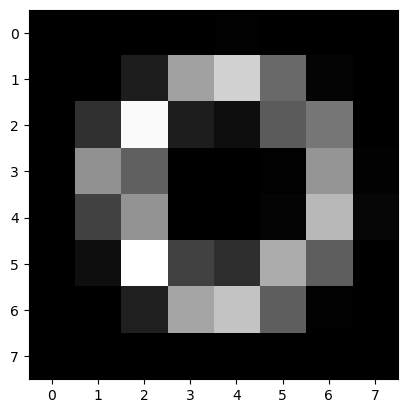

In [66]:
print("Original image at t=0")
state = states_diffused[0,n]
probs = (state*state.conj()).real
probs = probs[:, np.newaxis][:n_pixels]
image = probs.reshape(image_dim, image_dim)
norm = 1 / image.max()
image = image * norm
plt.imshow(image, vmin=vmin, vmax=vmax, cmap='gray')